In [1]:
import pandas as pd

In [2]:
df_13900K = pd.read_csv("MOLPIPx-set-bench-linear.csv")

df_13900K

,system,order,num_pips,num_flat_exponents,jit,run
0,A2B,3,13,20,0.702303,0.000403
1,A2B,4,22,35,0.714702,0.000292
2,A2B,5,34,56,0.715497,0.000175
3,A2B,6,50,84,0.716026,0.000217
4,A2B,7,70,120,0.725543,0.000376
...,...,...,...,...,...,...
79,ABCDE,4,1001,1001,0.782011,0.000315
80,ABCDE,5,3003,3003,0.789382,0.000229
81,ABCDE,6,8008,8008,0.802410,0.000224
82,ABCDE,7,19448,19448,0.854386,0.000406


In [5]:
from natsort import natsorted

In [6]:
system_list = natsorted(list(set(df_13900K["system"].values.tolist())))

system_list

['A2B',
 'A2B2',
 'A2B2C',
 'A2BC',
 'A2BCD',
 'A3',
 'A3B',
 'A3BC',
 'A4',
 'A4B',
 'A5',
 'ABC',
 'ABCD',
 'ABCDE']

In [7]:
import scienceplots

from matplotlib import pyplot as plt

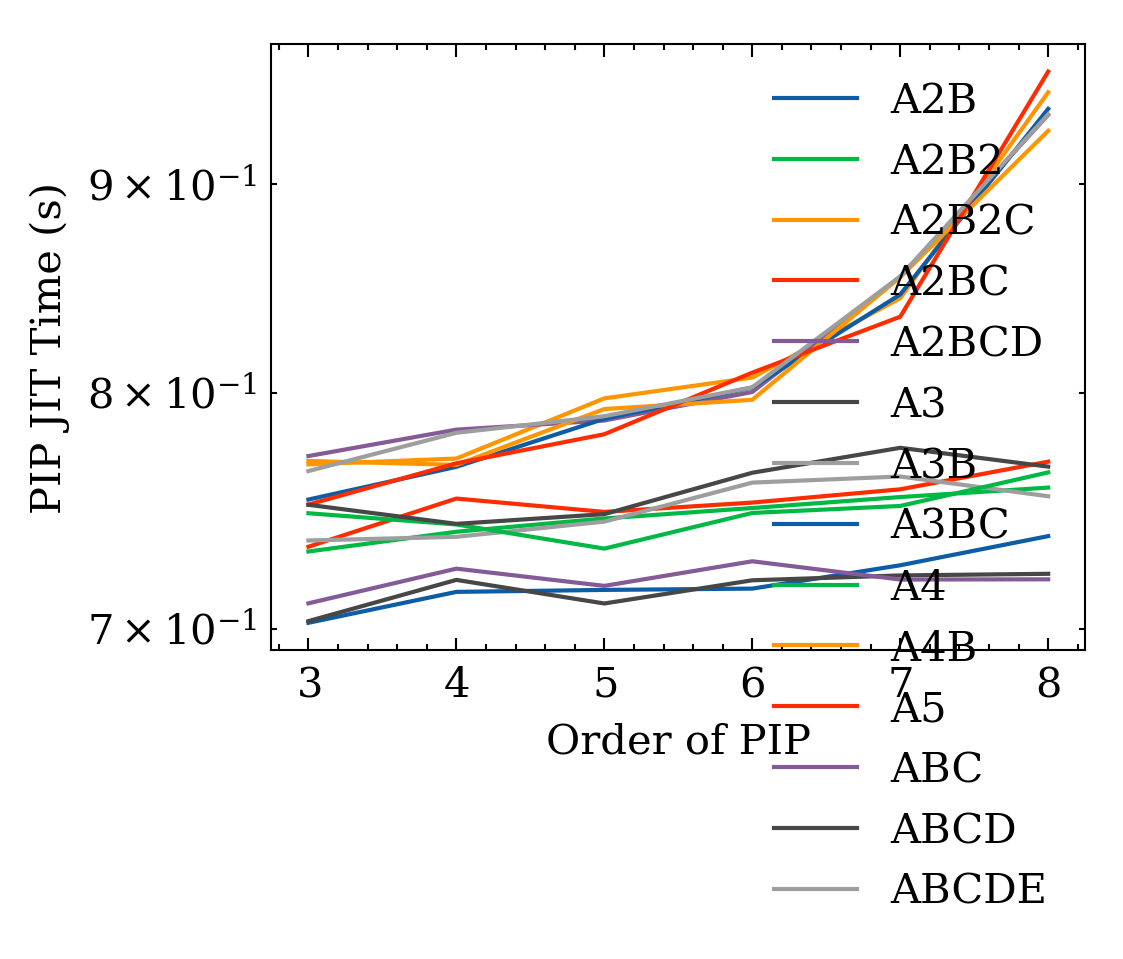

In [8]:
%matplotlib inline

with plt.style.context(["science", "no-latex"]):
    fig = plt.figure(dpi=300)
    ax = fig.add_subplot(111)

    for system in system_list:
        ax.plot(
            df_13900K[df_13900K["system"] == system]["order"],
            df_13900K[df_13900K["system"] == system]["jit"],
            label=f"{system}",
        )

    ax.set_yscale("log")

    ax.legend()

    ax.set_xlabel("Order of PIP")
    ax.set_ylabel("PIP JIT Time (s)")

plt.show()

In [10]:
import numpy as np

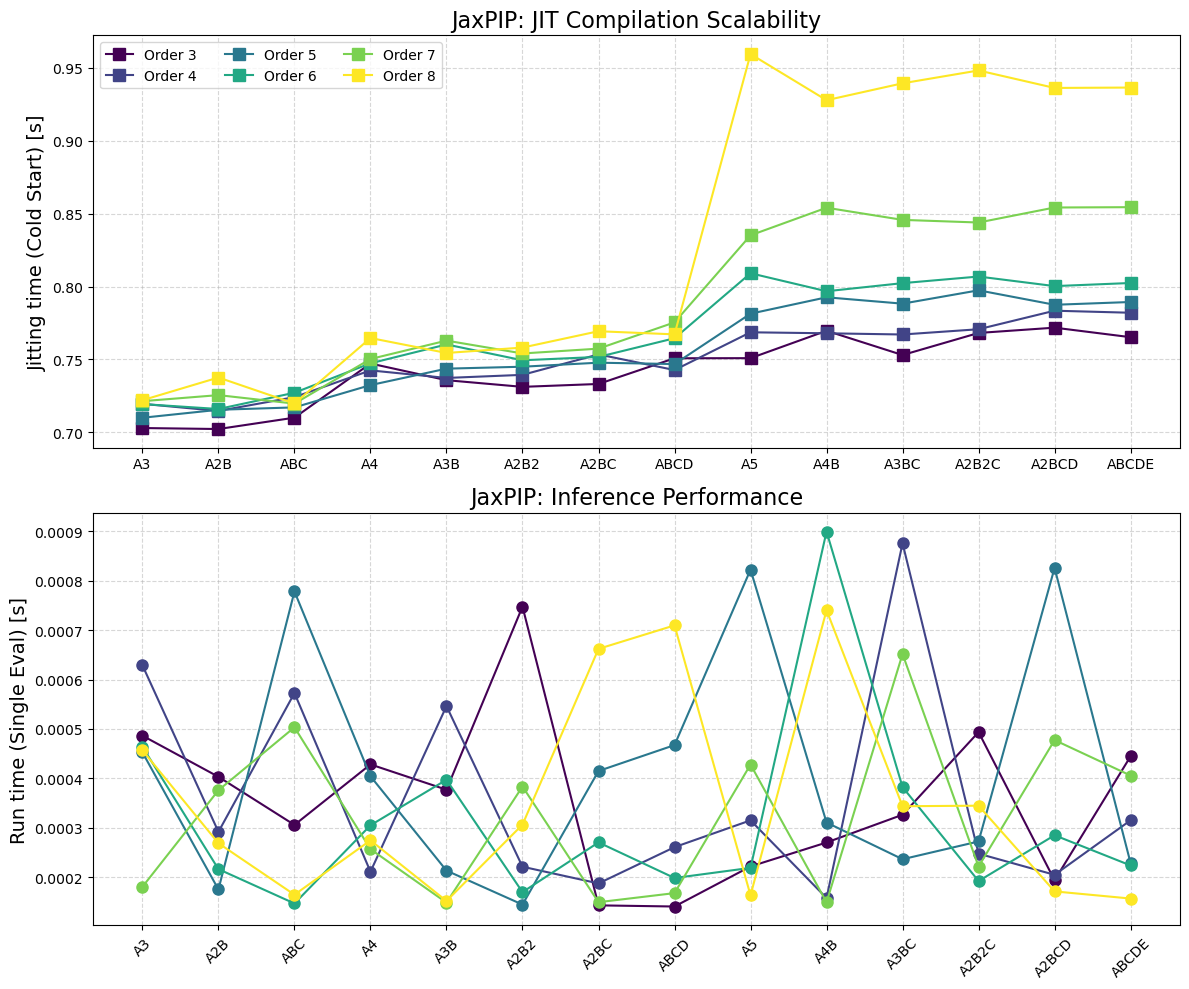

In [12]:

df = pd.read_csv("MOLPIPx-set-bench-linear.csv")

# 排序逻辑：先按体系（A3, A4...），再按阶数
# 假设你的 system 名字是标准化的
systems_order = ['A3', 'A2B', 'ABC', 'A4', 'A3B', 'A2B2', 'A2BC', 'ABCD', 'A5', 'A4B', 'A3B2', 'A3BC', 'A2B2C', 'A2BCD', 'ABCDE']
df['system'] = pd.Categorical(df['system'], categories=systems_order, ordered=True)
df = df.sort_values(['system', 'order'])

# 2. 开始画图
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# --- 图 (a): Jitting Time ---
# 使用 Seaborn 风格或直接用循环画不同 order 的线
colors = plt.cm.viridis(np.linspace(0, 1, 6))
orders = sorted(df['order'].unique())

for i, order in enumerate(orders):
    subset = df[df['order'] == order]
    ax1.plot(subset['system'].astype(str), subset['jit'], 
             marker='s', label=f'Order {order}', color=colors[i], markersize=8)

# ax1.set_yscale('log')
# ax1.set_ylim(0.1, 10) # 你的数据在 0.8-1.0 左右
ax1.set_ylabel('Jitting time (Cold Start) [s]', fontsize=14)
ax1.set_title('JaxPIP: JIT Compilation Scalability', fontsize=16)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(ncol=3)

# --- 图 (b): Run Time ---
for i, order in enumerate(orders):
    subset = df[df['order'] == order]
    ax2.plot(subset['system'].astype(str), subset['run'], 
             marker='o', label=f'Order {order}', color=colors[i], markersize=8)

# ax2.set_yscale('log')
ax2.set_ylabel('Run time (Single Eval) [s]', fontsize=14)
ax2.set_title('JaxPIP: Inference Performance', fontsize=16)
ax2.grid(True, which="both", ls="--", alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("jaxpip_performance.png", dpi=300)
plt.show()
